<a href="https://colab.research.google.com/github/Startechb/Transfer-Learning-on-the-Ultralytics-African-Wildlife/blob/main/notebooks/African_Wildlife_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from google.colab import files
files.upload()   # pick kaggle.json in the dialog that appears

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sylvianjane","key":"5780ba616c6e9aa958e03b2f91e3f47c"}'}

In [33]:
!pip install -q kaggle
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets list -s african-wildlife

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
biancaferreira/african-wildlife                                 African Wildlife                                    469442673  2020-05-25 13:42:19.487000          10488        166  0.75             
lydia70/malaria-in-africa                                       Malaria in Africa                                       27285  2020-12-30 13:40:12.337000           5733         70  1                
rahmasleam/bird-speciees-dataset                                Bird Speciees Dataset                                15989371  2024-09-28 23:26:28.587000           4343         41  1                
cites

In [34]:
!mkdir -p /content/raw
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip -O /content/african-wildlife.zip
!unzip -q /content/african-wildlife.zip -d /content/raw
!find /content/raw -maxdepth 3 -type d | head -20
!echo "images:"; find /content/raw -type f -name "*.jpg" | wc -l
!echo "labels:"; find /content/raw -type f -name "*.txt" | wc -l

replace /content/raw/LICENSE.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: /content/raw
/content/raw/images
/content/raw/images/train
/content/raw/images/val
/content/raw/images/test
/content/raw/labels
/content/raw/labels/train
/content/raw/labels/val
/content/raw/labels/test
images:
1501
labels:
1505


In [35]:
!kaggle datasets list -s "cats in the wild"
!kaggle datasets list -s "big cats"

ref                                                         title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  ----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
dseidli/lcwlabeled-cats-in-the-wild                         LCW(Labeled Cats In The Wild)                   21984901525  2023-12-08 08:16:59.143000            520          9  0.75             
joebeachcapital/pet-cats-new-zealand                        Pet Cats New Zealand                                5024601  2024-01-19 02:44:25.920000            284         16  1                
georgemartvel/catflw                                        CatFLW                                           1446970985  2024-04-16 14:41:04.033000           1147         14  0.875            
sujaykapadnis/ecological-impacts-of

In [36]:
!kaggle datasets download -d gpiosenka/cats-in-the-wild-image-classification -p /content/raw_cats --unzip -q
!find /content/raw_cats -maxdepth 2 -type d | head -30
print("-" * 40)
# image count per class folder, restricted to the names we care about
!for d in /content/raw_cats/*/*; do n=$(ls "$d" 2>/dev/null | wc -l); echo "$n  $d"; done | grep -iE "lion|leopard"

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cats-in-the-wild-image-classification
License(s): CC0-1.0
/content/raw_cats
/content/raw_cats/train
/content/raw_cats/train/CARACAL
/content/raw_cats/train/CLOUDED LEOPARD
/content/raw_cats/train/AFRICAN LEOPARD
/content/raw_cats/train/JAGUAR
/content/raw_cats/train/SNOW LEOPARD
/content/raw_cats/train/CHEETAH
/content/raw_cats/train/PUMA
/content/raw_cats/train/LIONS
/content/raw_cats/train/OCELOT
/content/raw_cats/train/TIGER
/content/raw_cats/valid
/content/raw_cats/valid/CARACAL
/content/raw_cats/valid/CLOUDED LEOPARD
/content/raw_cats/valid/AFRICAN LEOPARD
/content/raw_cats/valid/JAGUAR
/content/raw_cats/valid/SNOW LEOPARD
/content/raw_cats/valid/CHEETAH
/content/raw_cats/valid/PUMA
/content/raw_cats/valid/LIONS
/content/raw_cats/valid/OCELOT
/content/raw_cats/valid/TIGER
/content/raw_cats/test
/content/raw_cats/test/CARACAL
/content/raw_cats/test/CLOUDED LEOPARD
/content/raw_cats/test/AFRICAN LEOPARD
/content/raw_cats/test/JA

In [37]:
import tensorflow as tf
import matplotlib.pyplot as plt
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [38]:
import os, shutil, collections
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt

DST = Path("/content/wildlife_5class")
print("5-class folder exists:", DST.exists())
print("raw wildlife exists:  ", Path("/content/raw/images").exists())
print("raw cats exists:      ", Path("/content/raw_cats").exists())
if DST.exists():
    print({d.name: len(list(d.glob("*"))) for d in sorted(DST.iterdir())})

5-class folder exists: True
raw wildlife exists:   True
raw cats exists:       True
{'buffalo': 370, 'elephant': 372, 'leopard': 246, 'lion': 238, 'rhino': 369}


In [39]:
import collections, shutil
from pathlib import Path

SRC_WILD, SRC_CATS = Path("/content/raw"), Path("/content/raw_cats")
DST = Path("/content/wildlife_5class"); shutil.rmtree(DST, ignore_errors=True)
IMG_EXT = {".jpg", ".jpeg", ".png"}
WILD_IDS = {0: "buffalo", 1: "elephant", 2: "rhino"}   # 3 = zebra -> dropped

stats = collections.Counter()
for img in (SRC_WILD / "images").rglob("*"):
    if img.suffix.lower() not in IMG_EXT: continue
    lbl = SRC_WILD / "labels" / img.parent.name / (img.stem + ".txt")
    if not lbl.exists(): stats["no_label"] += 1; continue
    ids = {int(l.split()[0]) for l in lbl.read_text().splitlines() if l.strip()}
    if len(ids) != 1: stats["skipped_multi_or_empty"] += 1; continue
    cid = ids.pop()
    if cid not in WILD_IDS: stats["skipped_zebra"] += 1; continue
    out = DST / WILD_IDS[cid]; out.mkdir(parents=True, exist_ok=True)
    shutil.copy(img, out / f"wild_{img.name}"); stats[WILD_IDS[cid]] += 1

def cat_class(folder):
    n = folder.lower()
    if n == "lions": return "lion"
    if n == "african leopard": return "leopard"
    return None

for img in SRC_CATS.rglob("*"):
    if img.suffix.lower() not in IMG_EXT: continue
    cls = cat_class(img.parent.name)
    if cls is None: continue
    out = DST / cls; out.mkdir(parents=True, exist_ok=True)
    shutil.copy(img, out / f"cat_{img.parent.parent.name}_{img.name}"); stats[cls] += 1

counts = {d.name: len(list(d.glob("*"))) for d in sorted(DST.iterdir())}
print(dict(stats)); print(counts)
assert counts == {"buffalo": 370, "elephant": 372, "leopard": 246, "lion": 238, "rhino": 369}, "counts differ from earlier run"
print("OK - identical to the earlier run")

{'rhino': 369, 'buffalo': 370, 'skipped_multi_or_empty': 18, 'skipped_zebra': 375, 'elephant': 372, 'leopard': 246, 'lion': 238}
{'buffalo': 370, 'elephant': 372, 'leopard': 246, 'lion': 238, 'rhino': 369}
OK - identical to the earlier run


In [40]:
import tensorflow as tf
import matplotlib.pyplot as plt
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [41]:
import random, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

SPLIT = Path("/content/split"); shutil.rmtree(SPLIT, ignore_errors=True)
paths, labels = [], []
for cls_dir in sorted(DST.iterdir()):
    for f in cls_dir.iterdir():
        paths.append(f); labels.append(cls_dir.name)

p_train, p_tmp, y_train, y_tmp = train_test_split(paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
p_val, p_test, y_val, y_test   = train_test_split(p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

for name, ps, ys in [("train", p_train, y_train), ("val", p_val, y_val), ("test", p_test, y_test)]:
    for f, y in zip(ps, ys):
        (SPLIT / name / y).mkdir(parents=True, exist_ok=True)
        shutil.copy(f, SPLIT / name / y / f.name)

print(pd.DataFrame({s: collections.Counter(y) for s, y in [("train", y_train), ("val", y_val), ("test", y_test)]}))

          train  val  test
rhino       258   55    56
lion        167   36    35
buffalo     259   55    56
elephant    260   56    56
leopard     172   37    37


In [42]:
IMG_SIZE, BATCH = (224, 224), 32
common = dict(image_size=IMG_SIZE, batch_size=BATCH, label_mode="int", seed=SEED)

train_ds = tf.keras.utils.image_dataset_from_directory(SPLIT/"train", shuffle=True,  **common)
val_ds   = tf.keras.utils.image_dataset_from_directory(SPLIT/"val",   shuffle=False, **common)
test_ds  = tf.keras.utils.image_dataset_from_directory(SPLIT/"test",  shuffle=False, **common)
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(class_names, NUM_CLASSES)

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 1116 files belonging to 5 classes.
Found 239 files belonging to 5 classes.
Found 240 files belonging to 5 classes.
['buffalo', 'elephant', 'leopard', 'lion', 'rhino'] 5


class weight and sanity checks

{'buffalo': 0.86, 'elephant': 0.86, 'leopard': 1.3, 'lion': 1.34, 'rhino': 0.87}
batch: (32, 224, 224, 3) <dtype: 'float32'> | pixel range: 0.0 - 255.0 | labels: [1 1 4 4 0 2 3 3]
Found 1116 files belonging to 5 classes.


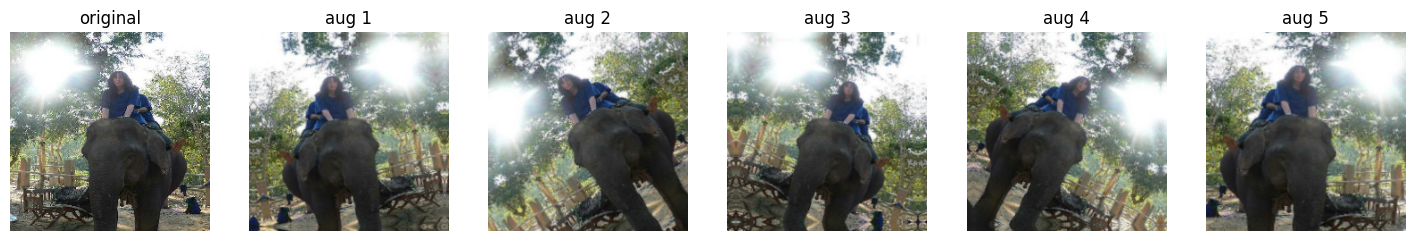

In [43]:
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.array(class_names), y=np.array(y_train))
class_weight = {i: float(w) for i, w in enumerate(cw)}
print({class_names[i]: round(w, 2) for i, w in class_weight.items()})

xb, yb = next(iter(train_ds))
print("batch:", xb.shape, xb.dtype, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)), "| labels:", yb.numpy()[:8])

raw = next(iter(tf.keras.utils.image_dataset_from_directory(SPLIT/"train", shuffle=True, **common)))[0][0]
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(raw.numpy().astype("uint8")); axes[0].set_title("original")
for i in range(1, 6):
    axes[i].imshow(augment(tf.expand_dims(raw, 0), training=True)[0].numpy().astype("uint8")); axes[i].set_title(f"aug {i}")
for a_ in axes: a_.axis("off")
plt.show()


 Experiment A, feature extraction (10 epochs)

In [44]:
from tensorflow.keras import layers, models

def build_model(num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.Lambda(tf.keras.applications.resnet50.preprocess_input, name="resnet_preprocess")(inputs)
    base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="resnet50_wildlife"), base

model, base = build_model()
n_train = sum(int(tf.size(w)) for w in model.trainable_weights)
print(f"Backbone layers: {len(base.layers)} | trainable params: {n_train:,} / {model.count_params():,}")
model.summary(show_trainable=True)

Backbone layers: 175 | trainable params: 525,829 / 24,113,541


Model: "resnet50_wildlife"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_8 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resnet_preprocess (Lambda)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resnet50 (Functional)       │ (None, 7, 7, 2048)    │ 23,587,712 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_3  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_6 (Dense)             │ (None, 256)           │    524,544 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 5)             │      1,285 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
import time, json
ART = Path("/content/artifacts"); ART.mkdir(exist_ok=True)

class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self._t = time.time()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.time() - self._t)

def run_experiment(tag, model, epochs, initial_epoch=0):
    timer = EpochTimer()
    ckpt = tf.keras.callbacks.ModelCheckpoint(str(ART / f"best_{tag}.weights.h5"), monitor="val_accuracy",
                                              save_best_only=True, save_weights_only=True)
    h = model.fit(train_ds, validation_data=val_ds, epochs=initial_epoch + epochs, initial_epoch=initial_epoch,
                  class_weight=class_weight, callbacks=[timer, ckpt])
    hist = {k: [float(v) for v in vals] for k, vals in h.history.items()}
    hist["epoch_time"] = timer.times
    (ART / f"history_{tag}.json").write_text(json.dumps(hist))
    print(f"\n[{tag}] best val acc = {max(hist['val_accuracy'])*100:.2f}% | mean epoch time = {np.mean(timer.times):.1f}s")
    return hist

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_A = run_experiment("A", model, epochs=10)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 39s 635ms/step - accuracy: 0.7921 - loss: 0.5025 - val_accuracy: 0.9707 - val_loss: 0.0956
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 371ms/step - accuracy: 0.9274 - loss: 0.1567 - val_accuracy: 0.9791 - val_loss: 0.0664
Epoch 3/10
18/35 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.9618 - loss: 0.0873

In [ ]:
base.trainable = True
first_unfrozen = [l.name for l in base.layers].index("conv5_block1_1_conv")
for l in base.layers[:first_unfrozen]:
    l.trainable = False
for l in base.layers:
    if isinstance(l, layers.BatchNormalization):
        l.trainable = False

n_train = sum(int(tf.size(w)) for w in model.trainable_weights)
n_layers = sum(1 for l in base.layers if l.trainable and l.weights)
print(f"Unfrozen from layer #{first_unfrozen} (conv5_block1_1_conv) | trainable weight-layers in backbone: {n_layers} | trainable params: {n_train:,} / {model.count_params():,}")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_B = run_experiment("B", model, epochs=10, initial_epoch=10)

In [ ]:
import json, numpy as np, pandas as pd
from pathlib import Path
from PIL import Image

ART = Path("/content/artifacts")
hist_A = json.loads((ART / "history_A.json").read_text())
hist_B = json.loads((ART / "history_B.json").read_text())
ep = np.arange(1, 21)
cat = lambda k: hist_A[k] + hist_B[k]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, key, title in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(ep, cat(key), "--", color="#1f77b4", alpha=0.7, label="train")
    ax.plot(ep, cat("val_" + key), "-o", color="#d95f02", label="validation")
    ax.axvline(10.5, color="gray", ls=":")
    ax.text(5.5, ax.get_ylim()[1], "A: frozen", ha="center", va="top", color="gray")
    ax.text(15.5, ax.get_ylim()[1], "B: fine-tune", ha="center", va="top", color="gray")
    ax.set(title=f"{title} (epochs 1-10: A, 11-20: B)", xlabel="epoch", ylabel=key); ax.grid(alpha=0.3)
    ax.legend(loc="lower right" if key == "accuracy" else "upper right")
plt.tight_layout(); plt.show()

Test evaluation for A and B


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

raw_test = tf.keras.utils.image_dataset_from_directory(SPLIT / "test", shuffle=False, **common)
y_true = np.concatenate([y.numpy() for _, y in raw_test])
test_files = raw_test.file_paths

results = {}
for tag in ["A", "B"]:
    m, _ = build_model()
    m.load_weights(str(ART / f"best_{tag}.weights.h5"))
    probs = m.predict(raw_test, verbose=0)
    pred = probs.argmax(1)
    results[tag] = dict(probs=probs, pred=pred, acc=float((pred == y_true).mean()),
                        macro_f1=float(f1_score(y_true, pred, average="macro")))
    print("=" * 60); print(f"Experiment {tag} | test accuracy {results[tag]['acc']*100:.2f}% | macro F1 {results[tag]['macro_f1']:.4f}")
    print(classification_report(y_true, pred, target_names=class_names, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, tag, name in zip(axes, "AB", ["A: Feature extraction", "B: Fine-tuning"]):
    ConfusionMatrixDisplay.from_predictions(y_true, results[tag]["pred"], display_labels=class_names, ax=ax,
                                            cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"Test confusion matrix - {name}")
plt.tight_layout(); plt.show()

In [ ]:
table = pd.DataFrame({
    "Metric Evaluated": ["Best Validation Accuracy", "Test Set Macro F1-Score", "Average Epoch Training Time"],
    "Experiment A (Feature Extraction)": [f"{max(hist_A['val_accuracy'])*100:.2f} %", f"{results['A']['macro_f1']:.4f}", f"{np.mean(hist_A['epoch_time']):.1f} sec"],
    "Experiment B (Fine-Tuning)":        [f"{max(hist_B['val_accuracy'])*100:.2f} %", f"{results['B']['macro_f1']:.4f}", f"{np.mean(hist_B['epoch_time']):.1f} sec"],
})
display(table)
table.to_csv(ART / "results_matrix.csv", index=False)
print("Median epoch time: A = %.1fs | B = %.1fs" % (np.median(hist_A["epoch_time"]), np.median(hist_B["epoch_time"])))

Error Analysis


In [ ]:
def error_table(tag):
    idx = np.where(results[tag]["pred"] != y_true)[0]
    return pd.DataFrame({"file": [Path(test_files[i]).name for i in idx],
                         "true": [class_names[y_true[i]] for i in idx],
                         "predicted": [class_names[results[tag]["pred"][i]] for i in idx],
                         "confidence": [round(float(results[tag]["probs"][i].max()), 3) for i in idx]}), idx

for tag in "AB":
    df, _ = error_table(tag); print(f"Experiment {tag}: {len(df)} / {len(y_true)} test images misclassified"); display(df)

def show_errors(tag, max_n=12):
    df, idx = error_table(tag)
    if len(idx) == 0: print("no errors"); return
    idx = idx[:max_n]; cols = min(4, len(idx)); rows = int(np.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows), squeeze=False)
    for a in axes.ravel(): a.axis("off")
    for a, i in zip(axes.ravel(), idx):
        a.imshow(Image.open(test_files[i]).convert("RGB"))
        a.set_title(f"true: {class_names[y_true[i]]}\npred: {class_names[results[tag]['pred'][i]]} ({results[tag]['probs'][i].max():.2f})", fontsize=10)
    plt.tight_layout(); plt.show()

print("Experiment B errors:"); show_errors("B")

In [ ]:
!cd /content && zip -qr artifacts.zip artifacts
from google.colab import files
files.download("/content/artifacts.zip")

In [ ]:
FIG = ART / "figures"; FIG.mkdir(exist_ok=True)
def save(fig, name): fig.savefig(FIG / name, dpi=160, bbox_inches="tight"); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, key, title in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(ep, cat(key), "--", color="#1f77b4", alpha=0.7, label="train")
    ax.plot(ep, cat("val_" + key), "-o", color="#d95f02", label="validation")
    ax.axvline(10.5, color="gray", ls=":")
    ax.set(title=f"{title}: A (epochs 1-10) | B (11-20)", xlabel="epoch", ylabel=key); ax.grid(alpha=0.3); ax.legend()
save(fig, "curves.png")

for tag, name in [("A", "Feature extraction"), ("B", "Fine-tuning")]:
    fig, ax = plt.subplots(figsize=(6, 5.5))
    ConfusionMatrixDisplay.from_predictions(y_true, results[tag]["pred"], display_labels=class_names, ax=ax,
                                            cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"Test confusion matrix - {tag}: {name}"); save(fig, f"cm_{tag}.png")

for tag in "AB":
    _, idx = error_table(tag)
    rows = int(np.ceil(len(idx) / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(15, 4.2 * rows), squeeze=False)
    for a in axes.ravel(): a.axis("off")
    for a, i in zip(axes.ravel(), idx):
        a.imshow(Image.open(test_files[i]).convert("RGB"))
        a.set_title(f"{Path(test_files[i]).name}\ntrue: {class_names[y_true[i]]} | pred: {class_names[results[tag]['pred'][i]]} ({results[tag]['probs'][i].max():.2f})", fontsize=10)
    save(fig, f"errors_{tag}.png")

np.savez(ART / "predictions.npz", y_true=y_true, files=np.array(test_files), class_names=np.array(class_names),
         probs_A=results["A"]["probs"], probs_B=results["B"]["probs"])

!rm -f /content/artifacts.zip && cd /content && zip -qr artifacts.zip artifacts
from google.colab import files
files.download("/content/artifacts.zip")

In [ ]:
import zipfile
small = list((ART / "figures").glob("*.png")) + [ART / "history_A.json", ART / "history_B.json",
                                                  ART / "results_matrix.csv", ART / "predictions.npz"]
with zipfile.ZipFile("/content/report_assets.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for f in small:
        z.write(f, f.relative_to(ART))
        print(f"{f.name:28s} {f.stat().st_size/1024:8.1f} KB")
print("zip size: %.2f MB" % (Path('/content/report_assets.zip').stat().st_size / 1e6))

from google.colab import files
files.download("/content/report_assets.zip")